# Predictive Analysis and Explainable AI (XAI)


In [186]:
!pip install shap xgboost lightgbm seaborn matplotlib pandas numpy scikit-learn nltk

In [187]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import shap
import random
import nltk


pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-darkgrid')


## Load Data

We load both artists and tracks.

In [188]:
try:
    df_artists = pd.read_csv('../dataset/cleaned_artists.csv', sep=None, index_col=0, engine='python', encoding='utf-8')
    df_tracks = pd.read_csv('../dataset/cleaned_tracks.csv')
    print(f"Artists: {df_artists.shape}")
    print(f"Tracks: {df_tracks.shape}")
except Exception as e:
    print("Error loading data. Ensure paths are correct.", e)



Artists: (104, 11)
Tracks: (11158, 45)


## NLP Feature Engineering (TF-IDF)

We extract top 2000 characteristic words from lyrics, removing the italian stopwords (such as li, l', gli, lo, le, la, etc...) which appear many times in a corpus and do not add any meaning to the sentence. This ensures that we are capturing the dialect/slang differences between regions.


In [189]:
nltk.download("stopwords")
from nltk.corpus import stopwords

df_tracks['lyrics'] = df_tracks['lyrics'].fillna('')
italian_stop_words = stopwords.words("italian")



# TF-IDF Vectorizer
# we make max_features=2000 ensures we don't overfit, capturing common slang
tfidf = TfidfVectorizer(max_features=2000, stop_words=italian_stop_words)

print("Fitting TF-IDF on lyrics...")
tfidf_matrix = tfidf.fit_transform(df_tracks['lyrics'])

tfidf_cols = [f'tfidf_{i}' for i in range(tfidf_matrix.shape[1])]
df_tfidf = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf_cols, index=df_tracks.index)

df_tracks = pd.concat([df_tracks, df_tfidf], axis=1)

print(f"Added {len(tfidf_cols)} NLP features.")


Fitting TF-IDF on lyrics...


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/dieudonne/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Added 2000 NLP features.


In [190]:
df_artists.head()

,name,gender,birth_date,birth_place,nationality,active_start,province,region,latitude,longitude,id_artist
id_author,,,,,,,,,,,
ART82291002,99 posse,M,NaN,NaN,NaN,1991-01-01,Napoli,Campania,NaN,NaN,ART82291002
ART53496045,achille lauro,M,1990-07-11,Verona,Italia,2012-01-01,Verona,Veneto,45.442498,10.985738,ART53496045
ART18853907,alfa,M,NaN,NaN,NaN,2016-02-05,Milano,Lombardia,NaN,NaN,ART18853907
ART64265460,anna pepe,F,NaN,NaN,NaN,2019-03-17,provincia della Spezia,Liguria,NaN,NaN,ART64265460
ART75741740,articolo 31,M,NaN,NaN,NaN,1990-01-01,Milano,Lombardia,NaN,NaN,ART75741740


## Merge & Macro-Zone Definition

We then mapp the macro-zones based on the linguistic characteristics, capturing region(or an area) with their language influence(such as dialects or almost normal language highly used in their daily conversations and songs). Source: Domain knowledge.


Macro-zone schools distribution:
macro_zone
Milan_Drill_School         4085
Lyrical_Standard_School    3071
South_Dialect_School       2217
Roman_Slang_School         1785
Name: count, dtype: int64


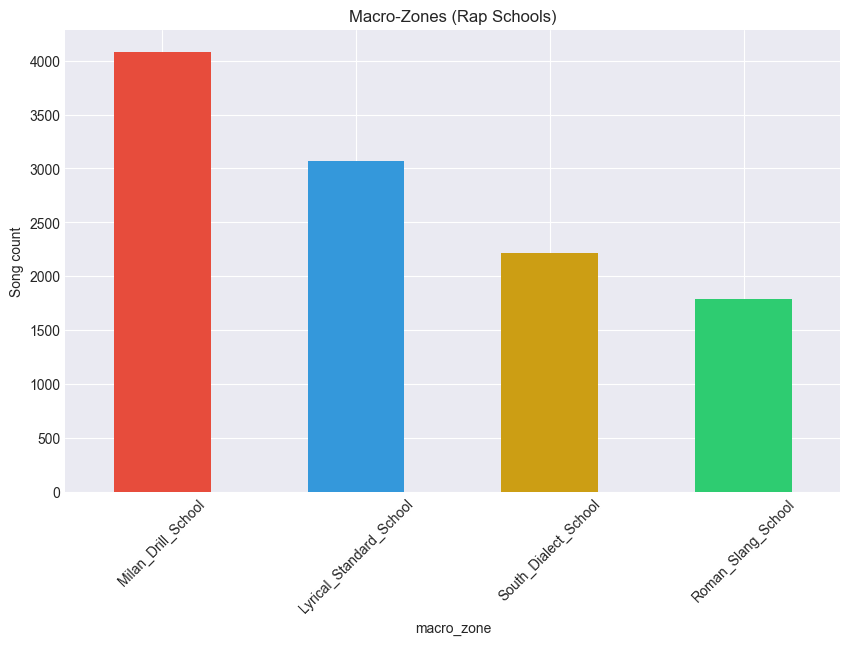

In [205]:
df_merged = pd.merge(df_tracks, df_artists, left_on='id_artist', right_index=True, how='inner')

macro_zone_mapping = {
    # Milan Drill
    'Lombardia': 'Milan_Drill_School',
    # Roman Slangs
    'Lazio': 'Roman_Slang_School',
    # South Dialects
    'Campania': 'South_Dialect_School',
    'Puglia': 'South_Dialect_School',
    'Sicilia': 'South_Dialect_School',
    'Calabria': 'South_Dialect_School',
    # Standard/Lyrical (North & Center)
    'Piemonte': 'Lyrical_Standard_School',
    'Veneto': 'Lyrical_Standard_School',
    'Liguria': 'Lyrical_Standard_School',
    'Trentino-Alto Adige': 'Lyrical_Standard_School',
    'Emilia-Romagna': 'Lyrical_Standard_School',
    'Toscana': 'Lyrical_Standard_School',
    'Marche': 'Lyrical_Standard_School',
    'Sardegna': 'Lyrical_Standard_School',
    'Umbria': 'Lyrical_Standard_School'
}

df_merged['macro_zone'] = df_merged['region'].map(macro_zone_mapping)

df_merged = df_merged.dropna(subset=['macro_zone'])

print("Macro-zone schools distribution:")
print(df_merged['macro_zone'].value_counts())

plt.figure(figsize=(10, 6))
df_merged['macro_zone'].value_counts().plot(kind='bar', color=['#e74c3c', '#3498db', "#cc9e14", '#2ecc71'])
plt.title('Macro-Zones (Rap Schools)')
plt.ylabel('Song count')
plt.xticks(rotation=45)
plt.show()


### Feature Selection

To ensure our models focus on meaningful, non-leaky information, we carefully selected input features:

- **Target:**  
  The target variable is `macro_zone`, representing the rap school or macro-region for each track.

- **Metadata Exclusion:**  
  We explicitly excluded all metadata and potentially leaky columns, such as artist IDs, names, locations, dates, and any demographic or popularity information. This prevents the model from "cheating" by using information that would not be available in a real-world prediction scenario.

- **Final Feature Set:**  
  Only numerical features not in the exclusion list are used for training. This includes engineered features (e.g., TF-IDF vectors, audio features) that are relevant for classification.

This approach ensures that our models learn from the actual content and characteristics of the tracks, not from external or identifying information.

In [192]:
target_col = 'macro_zone'
y = df_merged[target_col]

metadata_cols = [
    'id_artist', 'id_track', 'name', 'id_album', 'track_id',
    'lyrics', 'description', 'birth_place', 'nationality', 'gender', 
    'region', 'province', 'country', 'macro_zone', 'latitude', 'longitude',
    'active_start', 'active_end', 'birth_date', 'active_start_dt',
    'active_start_year', 'min_track_year',
    'month', 'day', 'popularity', 'stats_pageviews', 'modified_popularity',
    'track_number', 'disc_number', 'swear_IT_words', 'swear_EN_words', 'collab_count', 'active_start_final', 'gender_code', 'year'
]

X = df_merged.select_dtypes(include=[np.number])
cols_to_drop = [c for c in metadata_cols if c in X.columns]
X = X.drop(columns=cols_to_drop)
X = X.fillna(0)
print(f"Selected {X.shape[1]} features dynamically.")
print(f"Feature Examples: {list(X.columns)}...")


Selected 2019 features dynamically.
Feature Examples: ['swear_IT', 'swear_EN', 'n_sentences', 'n_tokens', 'tokens_per_sent', 'char_per_tok', 'lexical_density', 'avg_token_per_clause', 'bpm', 'centroid', 'rolloff', 'flux', 'rms', 'zcr', 'flatness', 'spectral_complexity', 'pitch', 'loudness', 'duration_ms', 'tfidf_0', 'tfidf_1', 'tfidf_2', 'tfidf_3', 'tfidf_4', 'tfidf_5', 'tfidf_6', 'tfidf_7', 'tfidf_8', 'tfidf_9', 'tfidf_10', 'tfidf_11', 'tfidf_12', 'tfidf_13', 'tfidf_14', 'tfidf_15', 'tfidf_16', 'tfidf_17', 'tfidf_18', 'tfidf_19', 'tfidf_20', 'tfidf_21', 'tfidf_22', 'tfidf_23', 'tfidf_24', 'tfidf_25', 'tfidf_26', 'tfidf_27', 'tfidf_28', 'tfidf_29', 'tfidf_30', 'tfidf_31', 'tfidf_32', 'tfidf_33', 'tfidf_34', 'tfidf_35', 'tfidf_36', 'tfidf_37', 'tfidf_38', 'tfidf_39', 'tfidf_40', 'tfidf_41', 'tfidf_42', 'tfidf_43', 'tfidf_44', 'tfidf_45', 'tfidf_46', 'tfidf_47', 'tfidf_48', 'tfidf_49', 'tfidf_50', 'tfidf_51', 'tfidf_52', 'tfidf_53', 'tfidf_54', 'tfidf_55', 'tfidf_56', 'tfidf_57', 'tfidf_

### Label Encoding & Data Split

We encode the target classes as integers using `LabelEncoder` for compatibility with scikit-learn models.  
The dataset is then split into training and test sets (80/20), stratified to preserve class proportions.

In [193]:
le_target = LabelEncoder()
y_encoded = le_target.fit_transform(y)
print(f"Classes: {le_target.classes_}")


# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)


Classes: ['Lyrical_Standard_School' 'Milan_Drill_School' 'Roman_Slang_School'
 'South_Dialect_School']


## Model Training & Comparison

We trained and compared three models:

1. **Random Forest**  
   - A strong baseline model that handles non-linear relationships and feature interactions well.
2. **XGBoost**  
   - A powerful gradient boosting algorithm, often achieving high predictive performance, especially with structured/tabular data.
3. **LightGBM**  
   - An efficient gradient boosting framework, optimized for speed and memory usage, and particularly effective when working with a large number of features.

Each model was evaluated using cross-validation and a held-out test set to ensure robust comparison.

In [194]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import learning_curve, StratifiedKFold
from sklearn.metrics import f1_score, classification_report
from sklearn.calibration import CalibratedClassifierCV

# Convert to numpy arrays to avoid XGBoost compatibility issues with pandas DataFrames
if hasattr(X_train, 'values'):
    X_train = np.ascontiguousarray(X_train.values)
    X_test = np.ascontiguousarray(X_test.values)
else:
    X_train = np.ascontiguousarray(X_train)
    X_test = np.ascontiguousarray(X_test)

## Grid Search

In [195]:

# param_grids = {
#     'RandomForest': {
#         'n_estimators': [50, 80, 100, 150],
#         'max_depth': [4, 8, 15, 20],       
#         'min_samples_leaf': [2, 4] 
#     },
#     'XGBoost': {
#         'n_estimators': [200, 300],
#         'learning_rate': [0.05, 0.1],    
#         'max_depth': [6, 8, 10],         
#         'reg_alpha': [0.1, 1.0],         
#         'reg_lambda': [0.1, 1.0],
#         'subsample': [0.8],
#         'colsample_bytree': [0.8]
#     },
#     'LightGBM': {
#         'n_estimators': [200, 300],
#         'learning_rate': [0.05, 0.1],
#         'num_leaves': [31, 50],         
#         'reg_alpha': [0.1, 1.0],
#         'reg_lambda': [0.1, 1.0],
#         'subsample': [0.8],
#         'colsample_bytree': [0.8]
#     }
# }

param_grids = {
    'RandomForest': {
        'n_estimators': [80, 100],
        'max_depth': [3, 5, 7],           # Lower depth forces generalization
        'min_samples_leaf': [10, 20]      # Forces larger groups at each leaf
    },
    'XGBoost': {
        'n_estimators': [50, 100],        # Fewer trees to prevent memorization
        'learning_rate': [0.01, 0.05],    # Slower learning is more stable
        'max_depth': [3, 4],              # Shallow trees are much harder to overfit
        'reg_alpha': [20, 50],             # HEAVY regularization
        'subsample': [0.7]
    },
    'LightGBM': {
        'n_estimators': [50, 100],
        'learning_rate': [0.01, 0.05],
        'num_leaves': [7, 15],            # Small leaf count is the best way to stop LGBM overfitting
        'min_child_samples': [20, 50],    # Force at least 50 samples per leaf
        'reg_lambda': [20, 50]
    }
}



### Train Models with grid search and cross validation


In [196]:
from sklearn.model_selection import RandomizedSearchCV

base_models = {
    'RandomForest': RandomForestClassifier(random_state=42, n_jobs=-1),
    'XGBoost': xgb.XGBClassifier(eval_metric='mlogloss', random_state=42, n_jobs=-1),
    'LightGBM': lgb.LGBMClassifier(random_state=42, verbose=-1, n_jobs=-1)
}

print("HYPERPARAMETER TUNING WITH RANDOM_SEARCH")

tuned_models = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in base_models.items():
    print(f"\nTuning {name}...")
    # grid = GridSearchCV(
    #     model, 
    #     param_grids[name], 
    #     cv=cv, 
    #     scoring='f1_macro', 
    #     n_jobs=-1, 
    #     verbose=1
    # )
    # grid.fit(X_train, y_train)
    
    # print(f"   Best Params: {grid.best_params_}")
    # print(f"   Best CV F1:  {grid.best_score_:.4f}")
    
    random_search = RandomizedSearchCV(
        model,
        param_distributions=param_grids[name],
        cv=cv,
        scoring='f1_macro',
        n_jobs=-1,
        verbose=1,
        random_state=42
    )
    random_search.fit(X_train, y_train)
    print(f"   Best Params: {random_search.best_params_}")
    print(f"   Best CV F1:  {random_search.best_score_:.4f}")
    tuned_models[name] = random_search.best_estimator_
    
    # tuned_models[name] = grid.best_estimator_.  #this is for the gridSearch

HYPERPARAMETER TUNING WITH RANDOM_SEARCH

Tuning RandomForest...
Fitting 5 folds for each of 10 candidates, totalling 50 fits
   Best Params: {'n_estimators': 80, 'min_samples_leaf': 10, 'max_depth': 7}
   Best CV F1:  0.3027

Tuning XGBoost...
Fitting 5 folds for each of 10 candidates, totalling 50 fits
   Best Params: {'subsample': 0.7, 'reg_alpha': 20, 'n_estimators': 100, 'max_depth': 4, 'learning_rate': 0.05}
   Best CV F1:  0.4394

Tuning LightGBM...
Fitting 5 folds for each of 10 candidates, totalling 50 fits


/opt/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/pytho

   Best Params: {'reg_lambda': 20, 'num_leaves': 15, 'n_estimators': 100, 'min_child_samples': 50, 'learning_rate': 0.05}
   Best CV F1:  0.5432


### Learning curves
We then show the learning curves for the cross validation to understand hiw the models are working on our data during k-fold cross validation

LEARNING CURVES


/opt/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/pytho

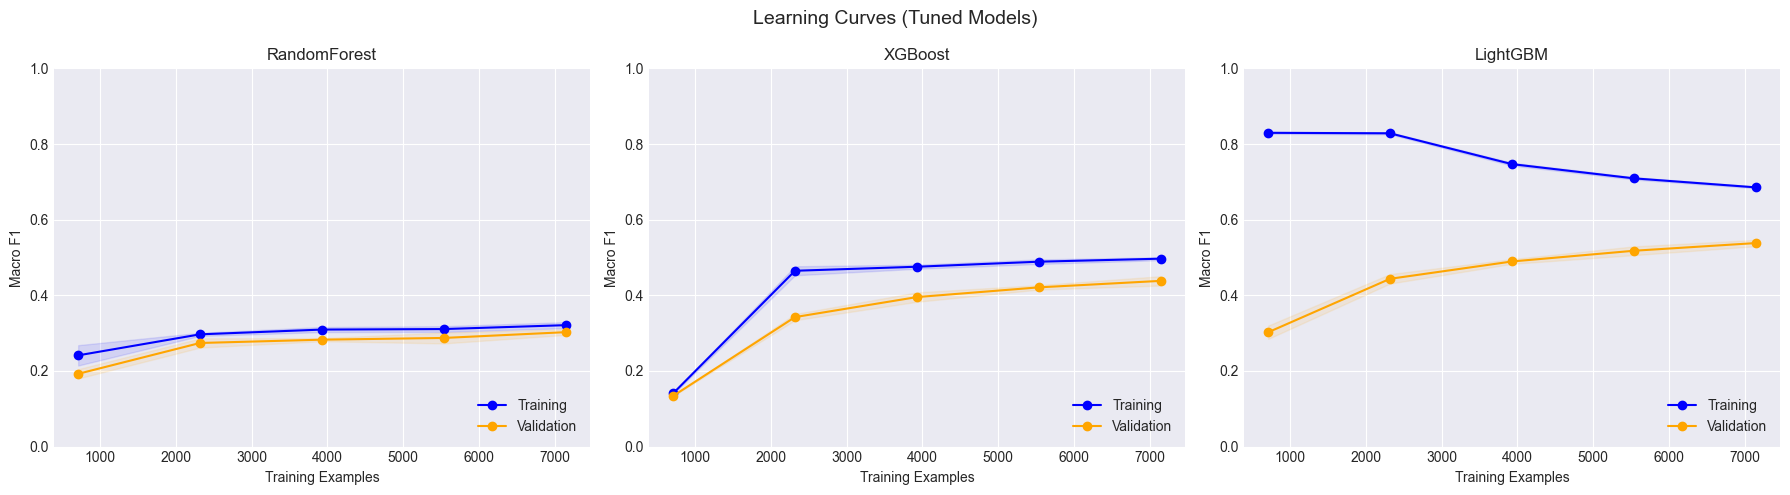

In [197]:
print("LEARNING CURVES")

fig, axes = plt.subplots(1, len(tuned_models), figsize=(18, 5)) 

for i, (name, model) in enumerate(tuned_models.items()): 
    train_sizes, train_scores, test_scores = learning_curve(
        model, X_train, y_train, cv=cv, scoring='f1_macro', n_jobs=-1, 
        train_sizes=np.linspace(0.1, 1.0, 5), random_state=42
    )
    
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)
    
    ax = axes[i]
    ax.plot(train_sizes, train_mean, 'o-', color="blue", label="Training")
    ax.plot(train_sizes, test_mean, 'o-', color="orange", label="Validation")
    ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="blue")
    ax.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color="orange")
    ax.set_title(f"{name}")
    ax.set_xlabel("Training Examples")
    ax.set_ylabel("Macro F1")
    ax.legend(loc="lower right")
    ax.grid(True)
    ax.set_ylim(0, 1)

plt.suptitle("Learning Curves (Tuned Models)", fontsize=14)
plt.tight_layout()
plt.show()


### Final training and test evaluation with early stopping 

We then train and test the models with ealry stopping: This ensures that the models stop the training when the loss is not reducing to avoid overfitting


In [198]:
print("FINAL TRAINING & TEST EVALUATION")

results = {}
trained_models = {}

for name, model in tuned_models.items():
    print(f"\nTraining {name}...")
    
    if name == 'XGBoost':
        # Set early_stopping_rounds on the model before fitting
        model.set_params(early_stopping_rounds=50)
        eval_set = [(X_train, y_train), (X_test, y_test)]
        model.fit(X_train, y_train, eval_set=eval_set, verbose=False)
        print(f" Stopped at epoch {model.best_iteration}")
        
    elif name == 'LightGBM':
        eval_set = [(X_train, y_train), (X_test, y_test)]
        callbacks = [lgb.early_stopping(stopping_rounds=50, verbose=False)]
        model.fit(X_train, y_train, eval_set=eval_set, eval_metric='multi_logloss', callbacks=callbacks)
        print(f" Stopped at epoch {model.best_iteration_}")
        
    else: # RandomForest (No early stopping, but we tuned depth)
        model.fit(X_train, y_train)
        
    y_pred = model.predict(X_test)
    f1 = f1_score(y_test, y_pred, average='macro')
    results[name] = f1
    trained_models[name] = model
    print(f" Test F1-Macro: {f1:.4f}")
    
    # Detailed Report
    print(f"\nClassification Report ({name}):")
    print(classification_report(y_test, y_pred, target_names=le_target.classes_))

FINAL TRAINING & TEST EVALUATION

Training RandomForest...
 Test F1-Macro: 0.3114

Classification Report (RandomForest):
                         precision    recall  f1-score   support

Lyrical_Standard_School       0.91      0.07      0.13       614
     Milan_Drill_School       0.40      0.99      0.57       817
     Roman_Slang_School       0.92      0.13      0.23       357
   South_Dialect_School       0.91      0.19      0.32       444

               accuracy                           0.44      2232
              macro avg       0.78      0.35      0.31      2232
           weighted avg       0.72      0.44      0.34      2232


Training XGBoost...
 Test F1-Macro: 0.3114

Classification Report (RandomForest):
                         precision    recall  f1-score   support

Lyrical_Standard_School       0.91      0.07      0.13       614
     Milan_Drill_School       0.40      0.99      0.57       817
     Roman_Slang_School       0.92      0.13      0.23       357
   South_Dia

/opt/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


## Final Results and training summary

In [199]:
# Summary
print("FINAL RESULTS SUMMARY")
for name, f1 in sorted(results.items(), key=lambda x: x[1], reverse=True):
    print(f"  {name}: {f1:.4f}")

best_model_name = max(results, key=results.get)
best_model = trained_models[best_model_name]
print(f"\nBest Model: {best_model_name}")

FINAL RESULTS SUMMARY
  LightGBM: 0.5570
  XGBoost: 0.4569
  RandomForest: 0.3114

Best Model: LightGBM


### Model Plots comparisons


/var/folders/29/j2385crd6f5dyk4l3185qktm0000gn/T/ipykernel_2060/57538320.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(results.keys()), y=list(results.values()), palette='viridis')


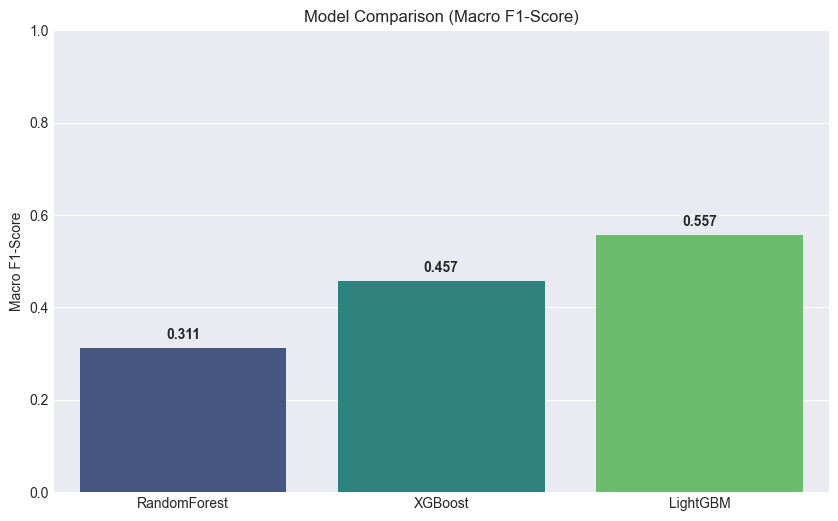


Best Model: LightGBM with F1-Macro: 0.5570


In [200]:
plt.figure(figsize=(10, 6))
sns.barplot(x=list(results.keys()), y=list(results.values()), palette='viridis')
plt.title('Model Comparison (Macro F1-Score)')
plt.ylabel('Macro F1-Score')
plt.ylim(0, 1.0)
for i, v in enumerate(results.values()):
    plt.text(i, v + 0.02, f"{v:.3f}", ha='center', fontweight='bold')
plt.show()

best_model_name = max(results, key=results.get)
best_model = tuned_models[best_model_name]
print(f"\nBest Model: {best_model_name} with F1-Macro: {results[best_model_name]:.4f}")


##  Learning curves of the models 

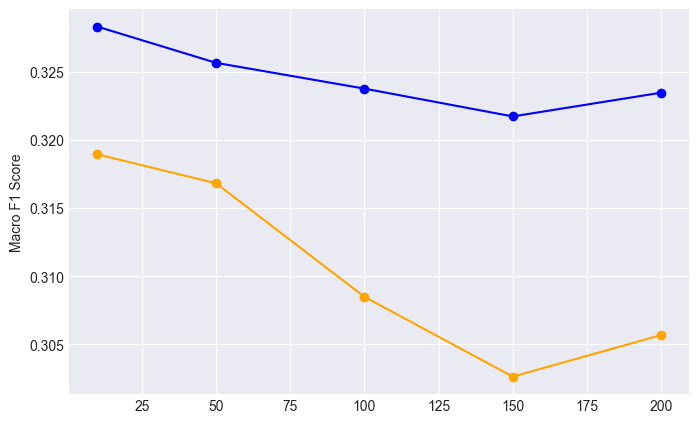

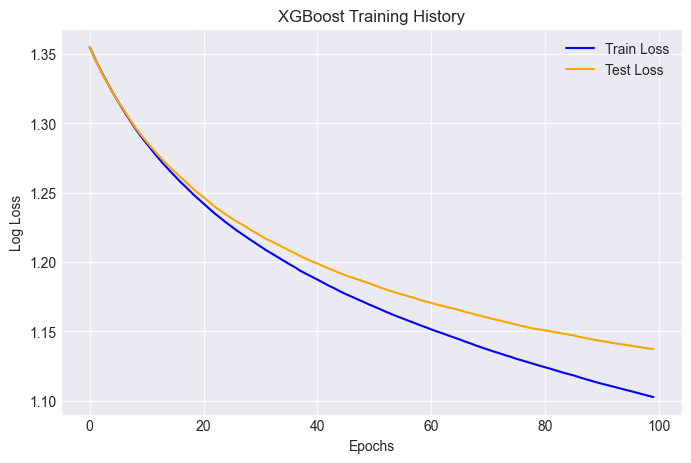

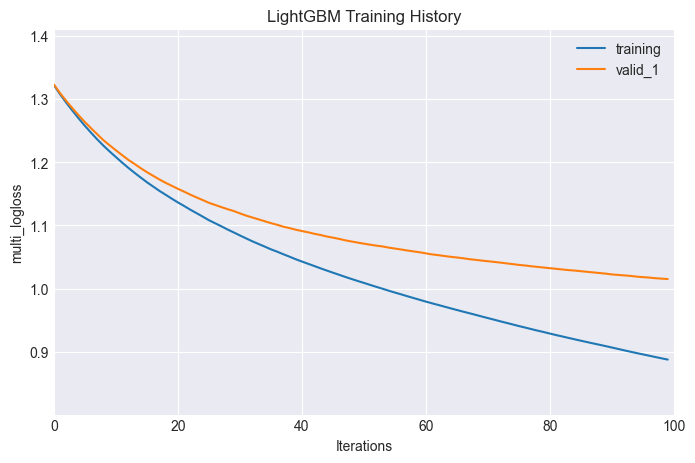

In [201]:
for name, model in tuned_models.items():
    plt.figure(figsize=(8, 5)) 
    
    if name == 'XGBoost':
        model_curve = xgb.XGBClassifier(**model.get_params())
        eval_set = [(X_train, y_train), (X_test, y_test)]
        model_curve.fit(X_train, y_train, eval_set=eval_set, verbose=False)
        results_curve = model_curve.evals_result()
        
        epochs = len(results_curve['validation_0']['mlogloss'])
        x_axis = range(0, epochs)
        
        plt.plot(x_axis, results_curve['validation_0']['mlogloss'], label='Train Loss', color='blue')
        plt.plot(x_axis, results_curve['validation_1']['mlogloss'], label='Test Loss', color='orange')
        plt.ylabel('Log Loss')
        plt.xlabel('Epochs')
        plt.title(f'XGBoost Training History')
        plt.legend()
        plt.grid(True)
        plt.show()
        
    elif name == 'LightGBM':
        model_curve = lgb.LGBMClassifier(**model.get_params())
        eval_set = [(X_train, y_train), (X_test, y_test)]
        callbacks = [lgb.log_evaluation(period=-1)]
        model_curve.fit(X_train, y_train, eval_set=eval_set, eval_metric='multi_logloss', callbacks=callbacks)
        
        lgb.plot_metric(model_curve, metric='multi_logloss', ax=plt.gca())
        plt.title(f'LightGBM Training History')
        plt.grid(True)
        plt.show()
        
    elif name == 'RandomForest':
        n_estimators_range = [10, 50, 100, 150, 200]
        train_scores = []
        test_scores = []
        
        base_params = model.get_params()
        
        for n in n_estimators_range:
            current_params = base_params.copy()
            current_params['n_estimators'] = n
            
            rf = RandomForestClassifier(**current_params)
            rf.fit(X_train, y_train)
            train_scores.append(f1_score(y_train, rf.predict(X_train), average='macro'))
            test_scores.append(f1_score(y_test, rf.predict(X_test), average='macro'))
            
        plt.plot(n_estimators_range, train_scores, 'o-', label='Train F1', color='blue')
        plt.plot(n_estimators_range, test_scores, 'o-', label='Test F1', color='orange')
        plt.ylabel('Macro F1 Score')

### Confusion matrix of the best model

/opt/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Classification Report for LightGBM:
                         precision    recall  f1-score   support

Lyrical_Standard_School       0.57      0.51      0.54       614
     Milan_Drill_School       0.54      0.80      0.65       817
     Roman_Slang_School       0.72      0.44      0.55       357
   South_Dialect_School       0.69      0.39      0.50       444

               accuracy                           0.58      2232
              macro avg       0.63      0.54      0.56      2232
           weighted avg       0.61      0.58      0.57      2232



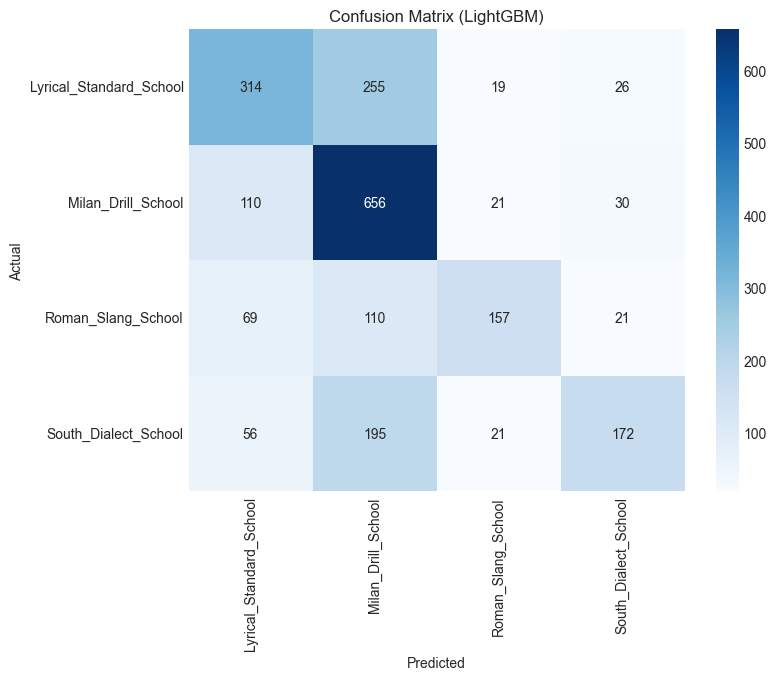

In [202]:
y_pred_best = best_model.predict(X_test)
print(f"Classification Report for {best_model_name}:")
print(classification_report(y_test, y_pred_best, target_names=le_target.classes_))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le_target.classes_, yticklabels=le_target.classes_)
plt.title(f'Confusion Matrix ({best_model_name})')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


### SHAP Explainability

To interpret our model predictions, we use SHAP (SHapley Additive exPlanations):

- **Feature Mapping:**  
  We map TF-IDF feature indices back to their original words for interpretability.

- **SHAP Explainer:**  
  For tree-based models (Random Forest, XGBoost, LightGBM), we use `TreeExplainer`.  
  For other models, we use `KernelExplainer`.

- **Visualization:**  
  The SHAP summary plot shows the most important features driving the model’s predictions, making it easier to understand which words or features are most influential for each rap school class to the model.

Feature names mapped.
Original: ['tfidf_1980', 'tfidf_1981', 'tfidf_1982', 'tfidf_1983', 'tfidf_1984', 'tfidf_1985', 'tfidf_1986', 'tfidf_1987', 'tfidf_1988', 'tfidf_1989', 'tfidf_1990', 'tfidf_1991', 'tfidf_1992', 'tfidf_1993', 'tfidf_1994', 'tfidf_1995', 'tfidf_1996', 'tfidf_1997', 'tfidf_1998', 'tfidf_1999']
Mapped:   ['when', 'white', 'who', 'with', 'woo', 'wow', 'ya', 'yah', 'ye', 'yeah', 'yeh', 'yes', 'yo', 'you', 'young', 'your', 'zero', 'zio', 'zitto', 'zona']

SHAP Shape: (2232, 2019, 4)

SHAP Shape: (2232, 2019, 4)


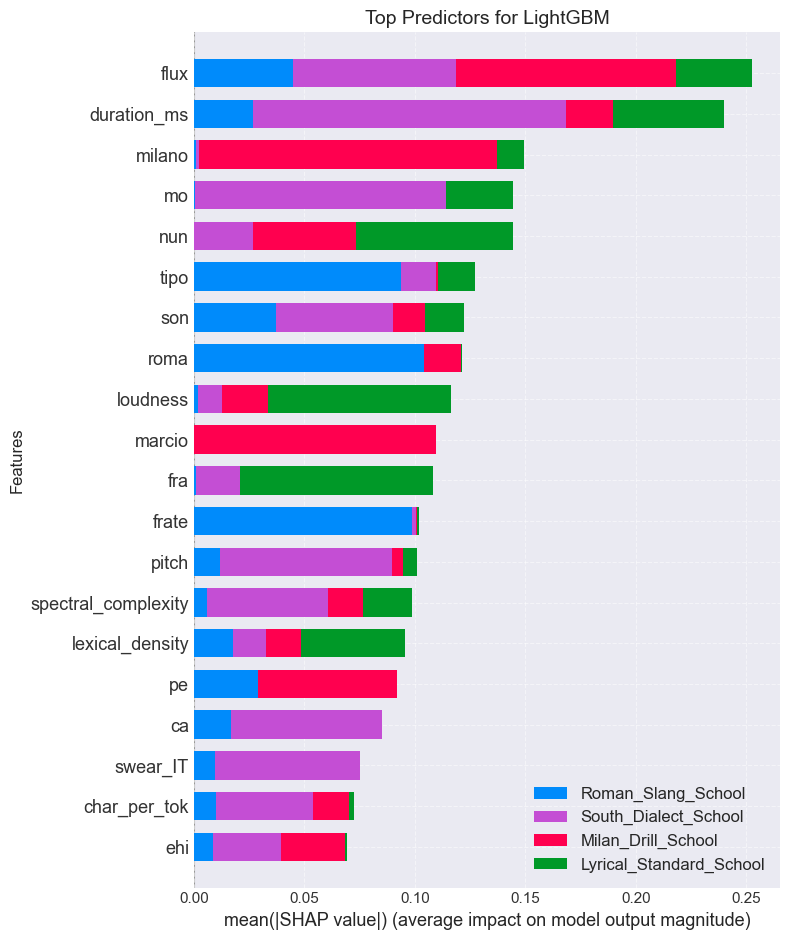

In [203]:
vocab = tfidf.get_feature_names_out()
feature_mapping = {f'tfidf_{i}': word for i, word in enumerate(vocab)}
display_feature_names = [feature_mapping.get(col, col) for col in X.columns]

print("Feature names mapped.")
print(f"Original: {list(X.columns)[-20:]}")
print(f"Mapped:   {display_feature_names[-20:]}")

if best_model_name in ['XGBoost', 'LightGBM', 'RandomForest']:
    explainer = shap.TreeExplainer(best_model)
    shap_explanation = explainer(X_test)
else:
    explainer = shap.KernelExplainer(best_model.predict_proba, X_train[:50])
    shap_explanation = explainer(X_test)

print(f"\nSHAP Shape: {shap_explanation.shape}")

plt.figure(figsize=(12, 8))
plt.title(f"Top Predictors for {best_model_name}", fontsize=14)
plt.xlabel("SHAP values - Impact on model output", fontsize=12)
plt.ylabel("Features", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

shap.summary_plot(
    shap_values=shap_explanation.values, 
    features=X_test,                     
    feature_names=display_feature_names, 
    class_names=le_target.classes_,      
    plot_type="bar"                     
)

plt.show()




### Local and Class-wise SHAP Explanations

- **Local Explanation:**  
  For a randomly selected test song, we use a SHAP waterfall plot to visualize the top features that most influenced the model’s prediction for that specific track and class.

  For each rap school class, we compute and display the top 10 most influential features (on average) across all test samples.  
  This helps identify which words or features are most characteristic for each class, providing deeper interpretability of the model’s decisions.

/opt/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Analyzing Song Index: 614
Song ID: TR860226
Artist: Nerone
Song Name: Sto Magazine Freestyle #12
Region: Lazio
Predicted Macrozone: Milan_Drill_School


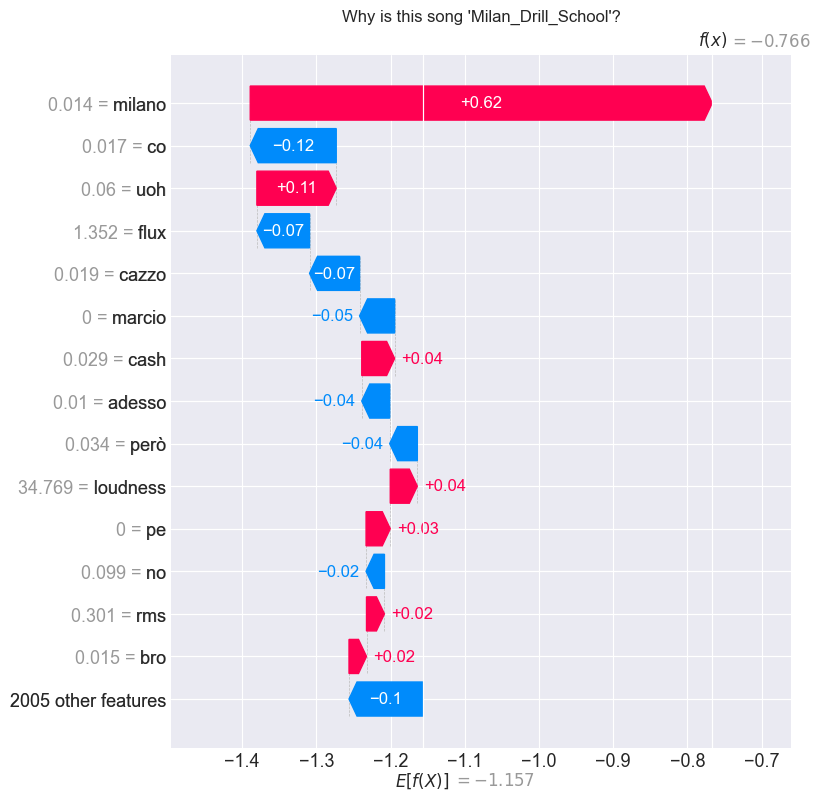

In [204]:
idx = random.randint(0, len(X_test)-1)

prediction_code = best_model.predict(X_test[idx].reshape(1, -1))[0]
predicted_class = le_target.inverse_transform([prediction_code])[0]
actual_class = le_target.inverse_transform([y_test[idx]])[0]

original_index = df_merged.iloc[idx].name
track_row = df_tracks.loc[original_index]

song_id = track_row['id']
artist_name = track_row['name_artist']
song_name = track_row['title']
region = df_merged.loc[original_index, 'region']

print(f"Analyzing Song Index: {idx}")
print(f"Song ID: {song_id}")
print(f"Artist: {artist_name}")
print(f"Song Name: {song_name}")
print(f"Region: {region}")
print(f"Predicted Macrozone: {predicted_class}")

shap_slice = shap_explanation[idx, :, int(prediction_code)]
shap_slice.feature_names = display_feature_names

plt.figure(figsize=(10, 10))
plt.title(f"Why is this song '{predicted_class}'?")
# max_display=15 shows the top 15 factors pushing the prediction up (red) or down (blue)
shap.plots.waterfall(shap_slice, max_display=15, show=False)
plt.show()
